# Churn Prediction — Stacking CV Ensemble

**วัตถุประสงค์:** ทำนาย churn probability ของลูกค้าแต่ละคน

| ชั้น | โมเดล |
|---|---|
| Level-0 (Base) | Random Forest, Extra Trees, XGBoost, LightGBM, Gradient Boosting |
| Level-1 (Meta) | Logistic Regression |

**Output:** `predictions.csv`

## 1. Import & Load Data

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/csv', exist_ok=True)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              roc_curve, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid')

df_raw.head()

df_raw = pd.read_csv('data/Ecommerce Customer Churn.csv')print(f'Shape: {df_raw.shape}')

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


## 2. EDA — ภาพรวมที่เกี่ยวข้องกับการทำนาย Churn

ก่อน train model เราดู distribution ของ features ที่คาดว่าจะสำคัญ และความสัมพันธ์กับ Churn

In [27]:
# Missing values
na_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
na_pct = na_pct[na_pct > 0].sort_values(ascending=False)
print('Missing values (%):'); print(na_pct)

# Class balance
print(f'\nChurn rate: {df_raw["Churn"].mean():.2%}  (imbalanced dataset)')
print(df_raw['Churn'].value_counts())

Missing values (%):
DaySinceLastOrder              5.45
OrderAmountHikeFromlastYear    4.71
Tenure                         4.69
OrderCount                     4.58
CouponUsed                     4.55
HourSpendOnApp                 4.53
WarehouseToHome                4.46
dtype: float64

Churn rate: 16.84%  (imbalanced dataset)
Churn
0    4682
1     948
Name: count, dtype: int64


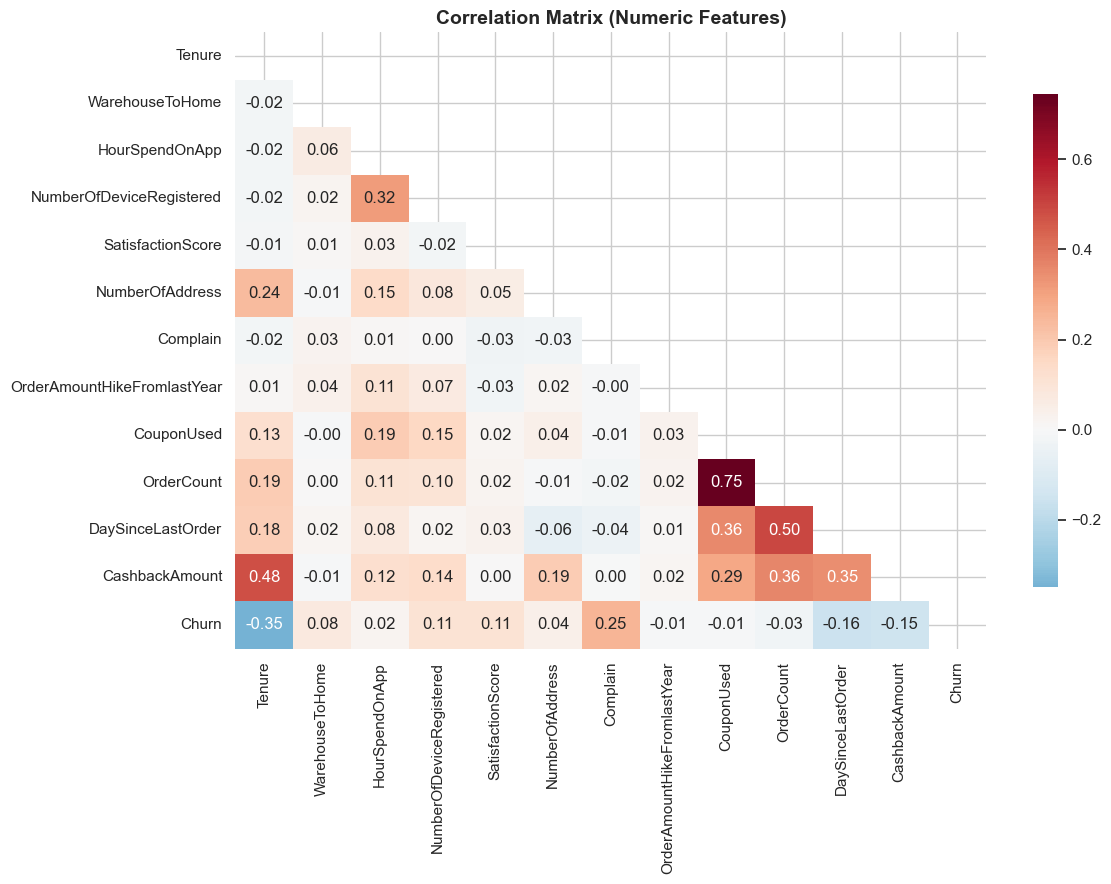

In [28]:
# Correlation Matrix — numeric features
num_cols = ['Tenure','WarehouseToHome','HourSpendOnApp','NumberOfDeviceRegistered',
            'SatisfactionScore','NumberOfAddress','Complain',
            'OrderAmountHikeFromlastYear','CouponUsed','OrderCount',
            'DaySinceLastOrder','CashbackAmount','Churn']

corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


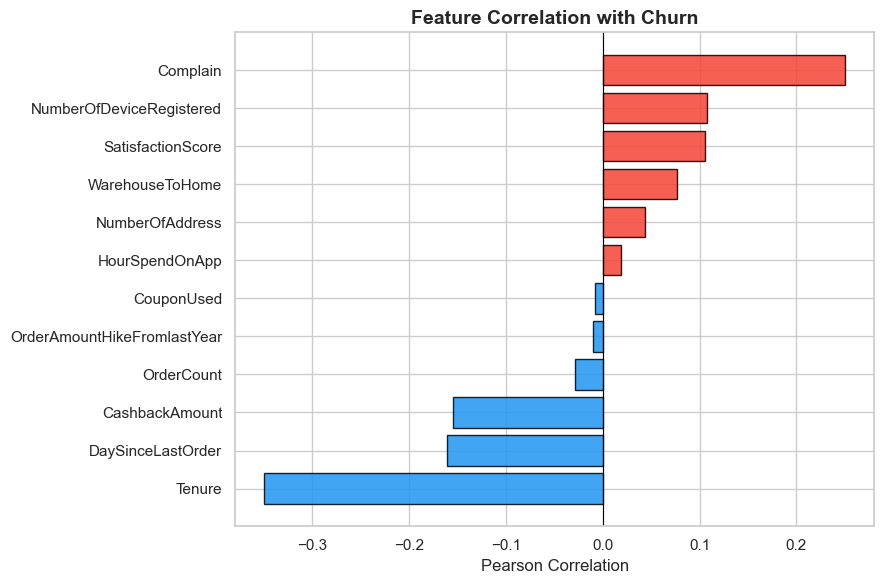

Top positive correlations (→ เสี่ยง churn สูง):
Complain                    0.250188
NumberOfDeviceRegistered    0.107939
SatisfactionScore           0.105481
WarehouseToHome             0.076630
NumberOfAddress             0.043931
HourSpendOnApp              0.018675

Top negative correlations (→ ลด churn):
Tenure                        -0.349408
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154161
OrderCount                    -0.028697
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264


In [29]:
# Feature Correlation with Churn — bar chart
churn_corr = corr['Churn'].drop('Churn').sort_values()
colors = ['#F44336' if v > 0 else '#2196F3' for v in churn_corr]

plt.figure(figsize=(9, 6))
plt.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', lw=0.8)
plt.title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Top positive correlations (→ เสี่ยง churn สูง):')
print(churn_corr[churn_corr > 0].sort_values(ascending=False).to_string())
print('\nTop negative correlations (→ ลด churn):')
print(churn_corr[churn_corr < 0].sort_values().to_string())


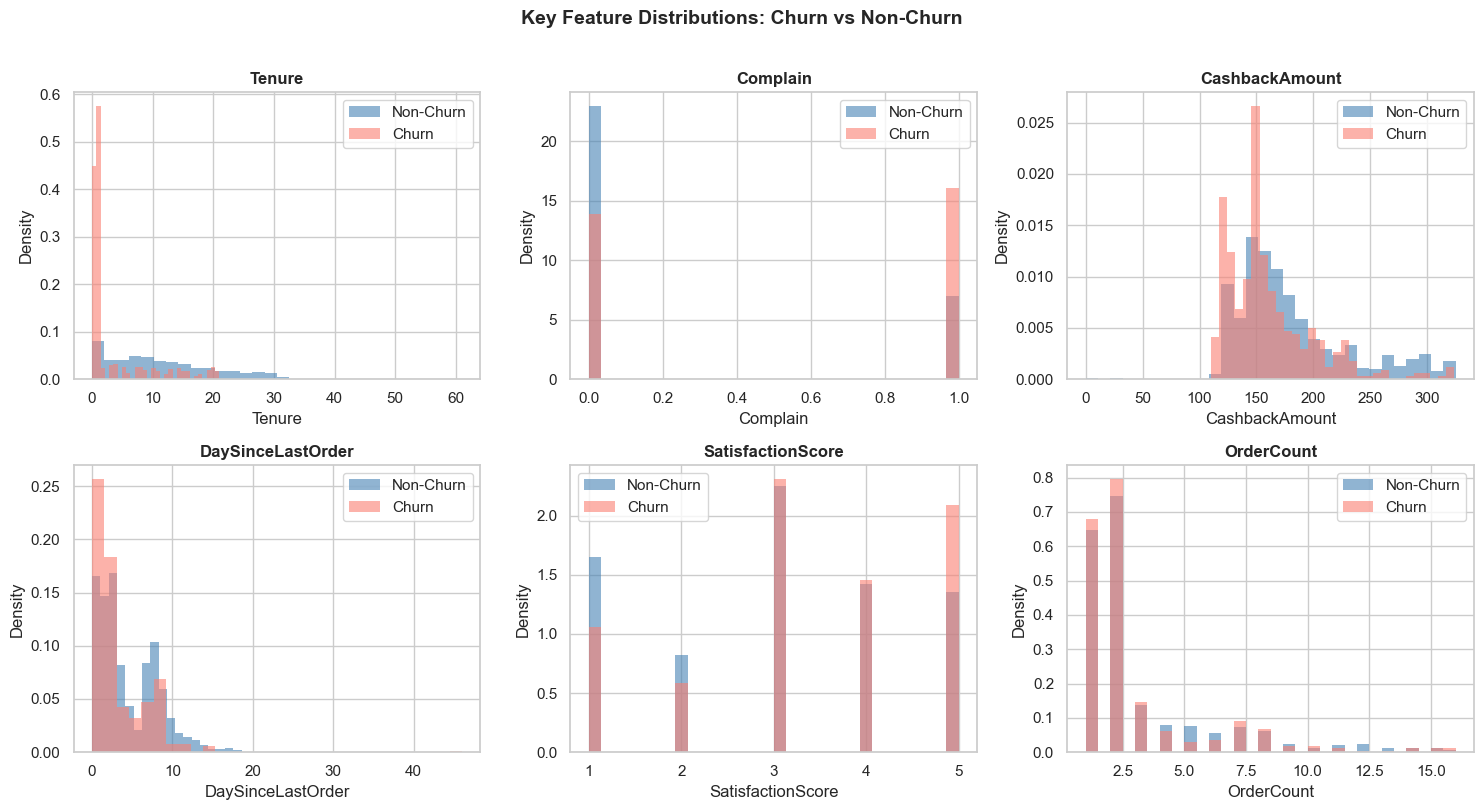

In [30]:
# Distribution ของ top features แยกตาม Churn
top_features = ['Tenure', 'Complain', 'CashbackAmount',
                'DaySinceLastOrder', 'SatisfactionScore', 'OrderCount']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    for val, label, color in [(0,'Non-Churn','steelblue'), (1,'Churn','salmon')]:
        sub = df_raw[df_raw['Churn'] == val][col].dropna()
        axes[i].hist(sub, bins=30, alpha=0.6, label=label, color=color,
                     density=True, edgecolor='none')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Key Feature Distributions: Churn vs Non-Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Preprocessing — Median Imputation + Encoding

In [31]:
df_clean = df_raw.copy()
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f'Missing values after imputation: {df_clean.isnull().sum().sum()}')

CAT_COLS = ['PreferredLoginDevice','PreferredPaymentMode',
            'Gender','PreferedOrderCat','MaritalStatus']
NUM_COLS = ['Tenure','CityTier','WarehouseToHome','HourSpendOnApp',
            'NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress',
            'Complain','OrderAmountHikeFromlastYear','CouponUsed',
            'OrderCount','DaySinceLastOrder','CashbackAmount']
TARGET = 'Churn'

df_ml = df_clean[CAT_COLS + NUM_COLS + [TARGET]].copy()
X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='ignore'), CAT_COLS)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor.fit(X_train)
ohe_names     = preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_COLS).tolist()
FEATURE_NAMES = NUM_COLS + ohe_names

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Total features: {len(FEATURE_NAMES)}')

Missing values after imputation: 0
Train: 4,504  |  Test: 1,126
Total features: 29


## 4. Base Model Comparison (5-Fold CV)

In [32]:
CV_FOLDS = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_estimators = [
    ('rf',   Pipeline([('pre', preprocessor), ('clf', RandomForestClassifier(
                n_estimators=300, min_samples_leaf=2,
                class_weight='balanced', random_state=42, n_jobs=-1))])),
    ('et',   Pipeline([('pre', preprocessor), ('clf', ExtraTreesClassifier(
                n_estimators=300, min_samples_leaf=2,
                class_weight='balanced', random_state=42, n_jobs=-1))])),
    ('xgb',  Pipeline([('pre', preprocessor), ('clf', XGBClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                eval_metric='logloss', random_state=42, n_jobs=-1))])),
    ('lgbm', Pipeline([('pre', preprocessor), ('clf', LGBMClassifier(
                n_estimators=300, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1))])),
    ('gb',   Pipeline([('pre', preprocessor), ('clf', GradientBoostingClassifier(
                n_estimators=200, max_depth=4, learning_rate=0.05,
                subsample=0.8, random_state=42))])),
]

print('กำลัง cross-validate base models...')
cv_results = {}
for name, pipe in base_estimators:
    roc = cross_val_score(pipe, X_train, y_train, cv=CV_FOLDS, scoring='roc_auc', n_jobs=-1)
    f1  = cross_val_score(pipe, X_train, y_train, cv=CV_FOLDS, scoring='f1',      n_jobs=-1)
    acc = cross_val_score(pipe, X_train, y_train, cv=CV_FOLDS, scoring='accuracy', n_jobs=-1)
    cv_results[name] = {'ROC-AUC': roc.mean(), 'ROC±': roc.std(),
                         'F1': f1.mean(), 'F1±': f1.std(),
                         'Accuracy': acc.mean()}
    print(f'  [{name:4s}] ROC-AUC={roc.mean():.4f}±{roc.std():.4f}  F1={f1.mean():.4f}  Acc={acc.mean():.4f}')

cv_df = pd.DataFrame(cv_results).T
display(cv_df.sort_values('ROC-AUC', ascending=False).round(4))

กำลัง cross-validate base models...
  [rf  ] ROC-AUC=0.9675±0.0076  F1=0.8203  Acc=0.9436
  [et  ] ROC-AUC=0.9712±0.0052  F1=0.8138  Acc=0.9403
  [xgb ] ROC-AUC=0.9652±0.0093  F1=0.8282  Acc=0.9405
  [lgbm] ROC-AUC=0.9706±0.0076  F1=0.8568  Acc=0.9509
  [gb  ] ROC-AUC=0.9468±0.0119  F1=0.7661  Acc=0.9296


,ROC-AUC,ROC±,F1,F1±,Accuracy
et,0.9712,0.0052,0.8138,0.0216,0.9403
lgbm,0.9706,0.0076,0.8568,0.0087,0.9509
rf,0.9675,0.0076,0.8203,0.0192,0.9436
xgb,0.9652,0.0093,0.8282,0.0148,0.9405
gb,0.9468,0.0119,0.7661,0.0312,0.9296


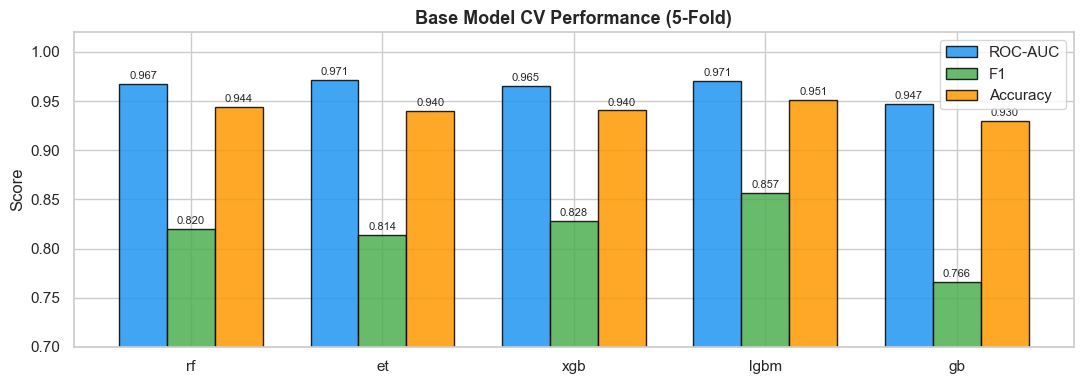

In [ ]:
x = np.arange(len(cv_df))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 4))
for i, (metric, color) in enumerate(zip(['ROC-AUC','F1','Accuracy'],
                                         ['#2196F3','#4CAF50','#FF9800'])):
    bars = ax.bar(x + i*width, cv_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels(cv_df.index, fontsize=11)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('Score')
ax.set_title('Base Model CV Performance (5-Fold)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/base_model_cv.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train Stacking CV Ensemble

In [34]:
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    cv=CV_FOLDS,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)
print('Training Stacking CV Ensemble...')
stacking_clf.fit(X_train, y_train)
print('✓ Training เสร็จแล้ว')

Training Stacking CV Ensemble...
✓ Training เสร็จแล้ว


## 6. Model Evaluation

In [35]:
y_pred       = stacking_clf.predict(X_test)
y_pred_proba = stacking_clf.predict_proba(X_test)[:, 1]

acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('=' * 55)
print('  STACKING CV ENSEMBLE — Test Set Results')
print('=' * 55)
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Non-Churn','Churn']))

  STACKING CV ENSEMBLE — Test Set Results
  Accuracy  : 0.9805
  F1 Score  : 0.9433
  ROC-AUC   : 0.9974
              precision    recall  f1-score   support

   Non-Churn       0.99      0.98      0.99       936
       Churn       0.92      0.96      0.94       190

    accuracy                           0.98      1126
   macro avg       0.96      0.97      0.97      1126
weighted avg       0.98      0.98      0.98      1126



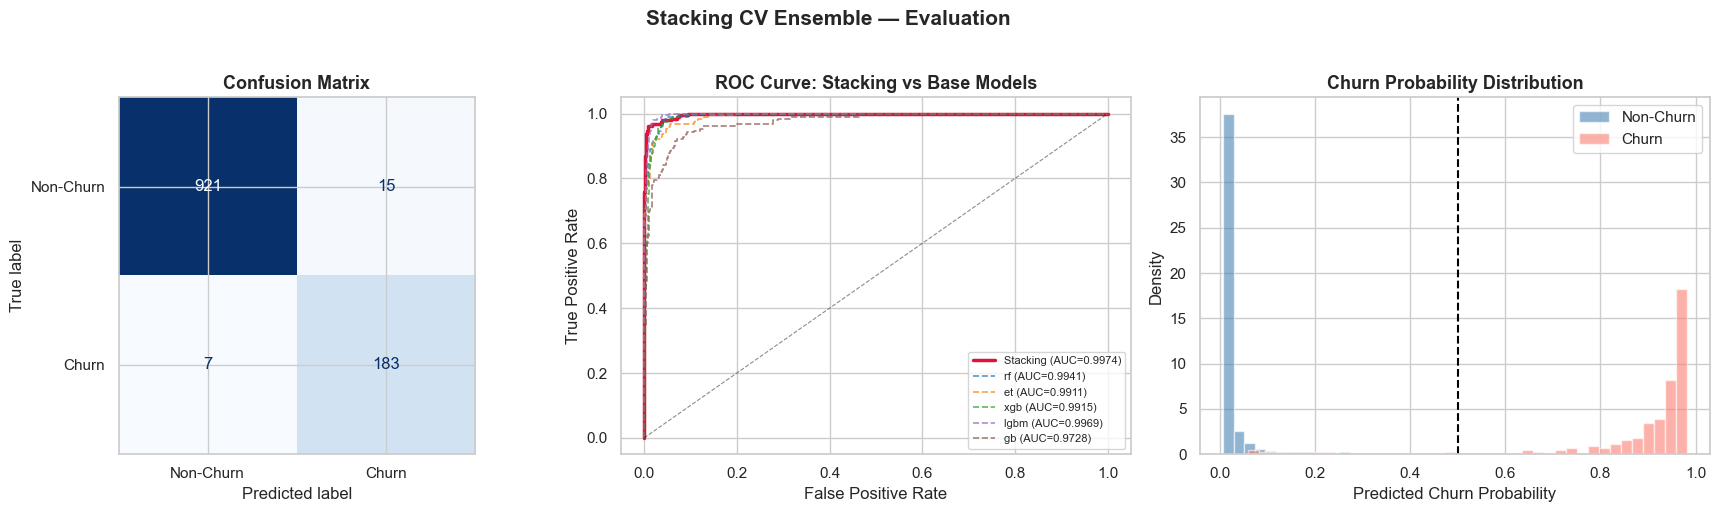

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                               display_labels=['Non-Churn','Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr_s, tpr_s, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr_s, tpr_s, color='crimson', lw=2.5,
             label=f'Stacking (AUC={roc_auc:.4f})')
base_colors = ['#1f77b4','#ff7f0e','#2ca02c','#9467bd','#8c564b']
for (name, pipe), color in zip(base_estimators, base_colors):
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    fpr_b, tpr_b, _ = roc_curve(y_test, prob)
    axes[1].plot(fpr_b, tpr_b, lw=1.2, linestyle='--', color=color, alpha=0.75,
                 label=f'{name} (AUC={roc_auc_score(y_test,prob):.4f})')
axes[1].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Stacking vs Base Models', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')

# Probability Distribution
df_res = pd.DataFrame({'prob': y_pred_proba, 'actual': y_test.values})
axes[2].hist(df_res[df_res['actual']==0]['prob'], bins=40, alpha=0.6,
             color='steelblue', label='Non-Churn', density=True)
axes[2].hist(df_res[df_res['actual']==1]['prob'], bins=40, alpha=0.6,
             color='salmon', label='Churn', density=True)
axes[2].axvline(0.5, color='black', linestyle='--', lw=1.5)
axes[2].set_xlabel('Predicted Churn Probability')
axes[2].set_ylabel('Density')
axes[2].set_title('Churn Probability Distribution', fontsize=13, fontweight='bold')
axes[2].legend()

plt.suptitle('Stacking CV Ensemble — Evaluation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/stacking_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance (MDI + Permutation)

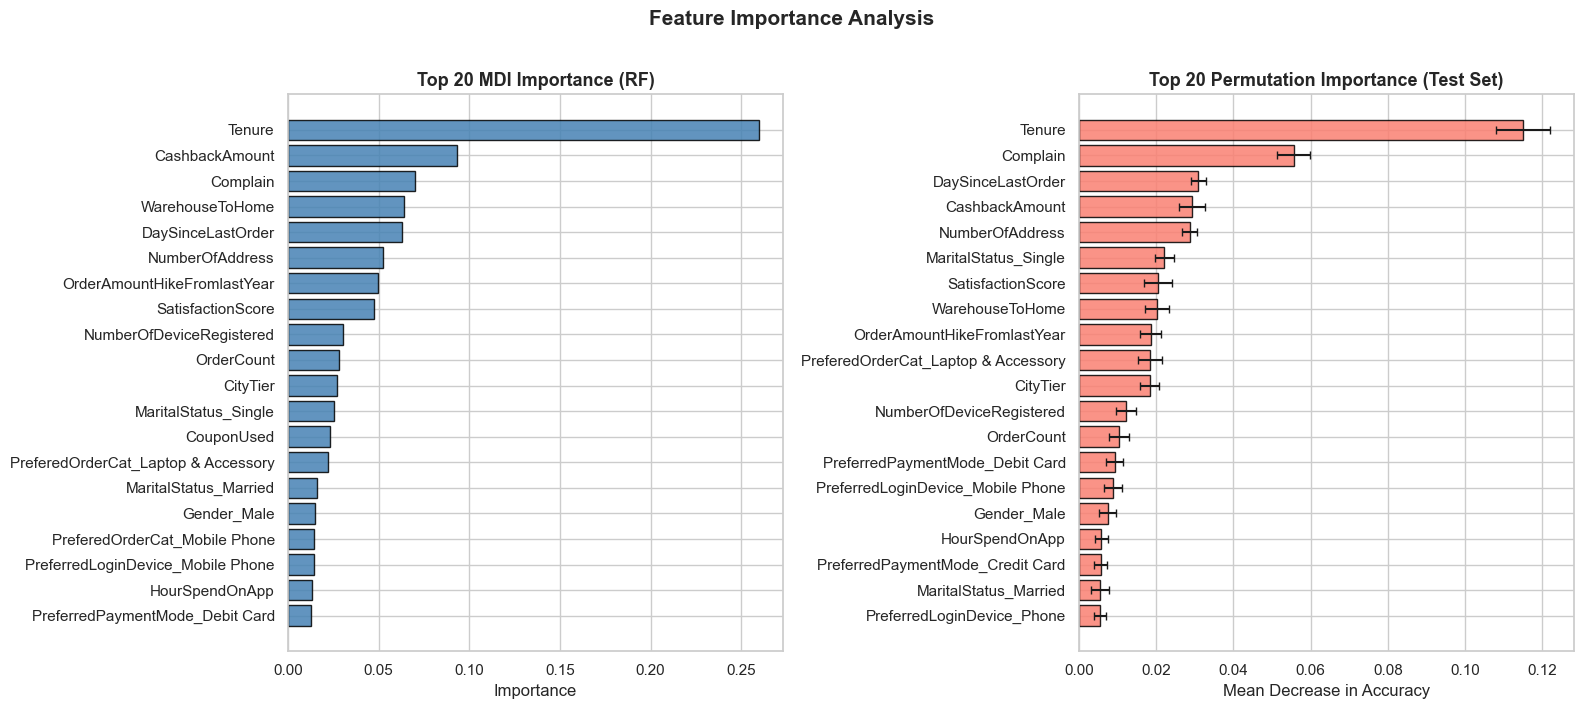

Top 10 Features (Permutation):
                            Feature  Perm_Mean  Perm_Std
                             Tenure   0.115038  0.007014
                           Complain   0.055595  0.004300
                  DaySinceLastOrder   0.030906  0.001924
                     CashbackAmount   0.029248  0.003454
                    NumberOfAddress   0.028656  0.002011
               MaritalStatus_Single   0.022084  0.002467
                  SatisfactionScore   0.020485  0.003676
                    WarehouseToHome   0.020130  0.003088
        OrderAmountHikeFromlastYear   0.018532  0.002632
PreferedOrderCat_Laptop & Accessory   0.018413  0.003067


In [ ]:
rf_pipe = stacking_clf.named_estimators_['rf']
rf_clf  = rf_pipe.named_steps['clf']
rf_pre  = rf_pipe.named_steps['pre']

fi_df = pd.DataFrame({'Feature': FEATURE_NAMES, 'MDI': rf_clf.feature_importances_})
fi_df = fi_df.sort_values('MDI', ascending=False).head(20)

perm = permutation_importance(rf_clf, rf_pre.transform(X_test), y_test,
                               n_repeats=15, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({'Feature': FEATURE_NAMES,
                         'Perm_Mean': perm.importances_mean,
                         'Perm_Std':  perm.importances_std})
perm_df = perm_df.sort_values('Perm_Mean', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(fi_df['Feature'][::-1], fi_df['MDI'][::-1],
             color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 20 MDI Importance (RF)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance')

axes[1].barh(perm_df['Feature'][::-1], perm_df['Perm_Mean'][::-1],
             xerr=perm_df['Perm_Std'][::-1],
             color='salmon', edgecolor='black', alpha=0.85, capsize=3)
axes[1].set_title('Top 20 Permutation Importance (Test Set)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Decrease in Accuracy')

plt.suptitle('Feature Importance Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 Features (Permutation):')
print(perm_df[['Feature','Perm_Mean','Perm_Std']].head(10).to_string(index=False))

## 8. Export Predictions → predictions.csv

In [ ]:
X_full     = df_ml.drop(columns=[TARGET])
churn_prob = stacking_clf.predict_proba(X_full)[:, 1]
churn_pred = stacking_clf.predict(X_full)

df_export = df_clean[['CustomerID','Churn','CashbackAmount','Tenure',
                       'OrderCount','DaySinceLastOrder','Complain',
                       'SatisfactionScore','CouponUsed',
                       'PreferredLoginDevice','PreferredPaymentMode',
                       'Gender','PreferedOrderCat','MaritalStatus']].copy()
df_export['Churn_Prob'] = churn_prob.round(4)
df_export['Churn_Pred'] = churn_pred

df_export.to_csv('outputs/csv/predictions.csv', index=False)
print(f'✓ Saved outputs/csv/predictions.csv  ({len(df_export):,} rows)')
display(df_export.head())

✓ Saved predictions.csv  (5,630 rows)


,CustomerID,Churn,CashbackAmount,Tenure,OrderCount,DaySinceLastOrder,Complain,SatisfactionScore,CouponUsed,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus,Churn_Prob,Churn_Pred
0,50001,1,160,4.0,1.0,5.0,1,2,1.0,Mobile Phone,Debit Card,Female,Laptop & Accessory,Single,0.9816,1
1,50002,1,121,9.0,1.0,0.0,1,3,0.0,Phone,UPI,Male,Mobile,Single,0.9685,1
2,50003,1,120,9.0,1.0,3.0,1,3,0.0,Phone,Debit Card,Male,Mobile,Single,0.9791,1
3,50004,1,134,0.0,1.0,3.0,0,5,0.0,Phone,Debit Card,Male,Laptop & Accessory,Single,0.9674,1
4,50005,1,130,0.0,1.0,3.0,0,5,1.0,Phone,CC,Male,Mobile,Single,0.9803,1
